# 01B — Field-calibrated CAISO + Alibaba + Emerald AI data preparation

This notebook is the **revised pre-D-Wave data/formulation pipeline**.

It combines:

1. real 2025 CAISO renewable-curtailment profiles;
2. real Alibaba 2026 Spot A100 jobs; and
3. the field-measured A100 DVFS power/throughput sweep released with the 2026 *Nature Energy* AI-data-centre field demonstration.

The important upgrade over the first formulation is that each binary candidate now specifies **job + start time + DVFS power cap**. The empirical job runtime is inflated by a conservative measured throughput factor so every admitted job still completes its baseline work within the six-hour event.

The frozen portfolio contains exactly **256 requested A100 GPUs in total**, matching the scale of the field demonstration. Therefore physical cluster capacity is automatically respected when each real job is admitted at most once.

In [7]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ai_spot_curtailment_dvfs_qubo_core import (
    StudyConfig, prepare_from_original_sources, build_qubo,
    random_equivalence_tests, greedy_physical_smoketest
)

# Edit only if your filenames differ.
CAISO_XLSX = Path("production-and-curtailments-data-2025.xlsx")
ALIBABA_ZIP = Path("clusterdata-master.zip")
EMERALD_ZIP = Path("emerald-ai-demo-may-2025-main.zip")
OUT = Path("prepared_ai_curtailment_dvfs")

# Common alternate filename from this collaboration.
if not EMERALD_ZIP.exists() and Path("emerald-ai-demo-may-2025-main(1).zip").exists():
    EMERALD_ZIP = Path("emerald-ai-demo-may-2025-main(1).zip")

CFG = StudyConfig()
print(CFG)
assert CFG.lambda_once > CFG.lambda_sufficient_bound
print(f"Rigorous duplicate-start penalty bound: lambda > {CFG.lambda_sufficient_bound:.3f}; using {CFG.lambda_once:g}")

StudyConfig(slot_minutes=15, event_hours=6, n_events=20, min_event_separation_hours=24, gpu_model='A100-SXM4-80GB', job_duration_min_minutes=90.0, job_duration_max_minutes=180.0, n_jobs_small=13, n_jobs_medium=4, n_jobs_large=1, seed_jobs=883, field_cluster_gpus=256, dvfs_caps_W=(250, 300, 350, 400), throughput_statistic='minimum', power_statistic='mean', field_flex_fraction=0.25, target_fraction_of_envelope=0.8, lambda_once=20.0, cplex_time_limit_s=30.0, cplex_mip_gap=0.01, sa_num_reads=1000, sa_num_sweeps=5000, sa_seed=20260903)
Rigorous duplicate-start penalty bound: lambda > 15.360; using 20


In [8]:
paths = prepare_from_original_sources(CAISO_XLSX, ALIBABA_ZIP, EMERALD_ZIP, OUT, CFG)
manifest = json.loads((OUT/"revised_data_and_qubo_manifest.json").read_text())
print(json.dumps(manifest, indent=2))

{
  "config": {
    "slot_minutes": 15,
    "event_hours": 6,
    "n_events": 20,
    "min_event_separation_hours": 24,
    "gpu_model": "A100-SXM4-80GB",
    "job_duration_min_minutes": 90.0,
    "job_duration_max_minutes": 180.0,
    "n_jobs_small": 13,
    "n_jobs_medium": 4,
    "n_jobs_large": 1,
    "seed_jobs": 883,
    "field_cluster_gpus": 256,
    "dvfs_caps_W": [
      250,
      300,
      350,
      400
    ],
    "throughput_statistic": "minimum",
    "power_statistic": "mean",
    "field_flex_fraction": 0.25,
    "target_fraction_of_envelope": 0.8,
    "lambda_once": 20.0,
    "cplex_time_limit_s": 30.0,
    "cplex_mip_gap": 0.01,
    "sa_num_reads": 1000,
    "sa_num_sweeps": 5000,
    "sa_seed": 20260903
  },
  "input_caiso": "/Users/kumarghosh/Desktop/other_projects_till_Jul_5/Energy_mix/GPU_opt/production-and-curtailments-data-2025.xlsx",
  "input_alibaba_zip": "/Users/kumarghosh/Desktop/other_projects_till_Jul_5/Energy_mix/GPU_opt/clusterdata-master.zip",
  "input_e

In [9]:
cal = pd.read_csv(OUT/"emerald_dvfs_calibration.csv")
events = pd.read_csv(OUT/"selected_caiso_events.csv", parse_dates=["start","end"])
profiles = pd.read_csv(OUT/"event_profiles_long.csv", parse_dates=["timestamp"])
portfolio = pd.read_csv(OUT/"benchmark_spot_jobs_dvfs.csv")
vt = pd.read_csv(OUT/"candidate_variable_table.csv")
greedy = pd.read_csv(OUT/"greedy_physical_smoketest.csv")

print("DVFS calibration")
display(cal)
print("Frozen 256-GPU portfolio")
display(portfolio[["portfolio_job_id","job_name","organization","total_gpus","duration_minutes"]])
print("Total requested GPUs:", portfolio.total_gpus.sum())
print("Candidate binaries:", len(vt))
print("Greedy feasibility smoke test (NOT a publication solver)")
display(greedy)

DVFS calibration


,power_cap_W,n_workload_profiles,power_per_gpu_W_mean,power_per_gpu_W_median,power_per_gpu_W_min,power_per_gpu_W_max,throughput_min,throughput_mean,throughput_median,throughput_max,model_power_per_gpu_kW,model_throughput_factor
0,250,8,243.079185,242.489666,239.823919,247.465799,0.780899,0.843215,0.870871,0.904225,0.243079,0.780899
1,300,8,289.330401,288.937500,285.541664,295.711446,0.859551,0.910126,0.930931,0.950704,0.289330,0.859551
2,350,8,330.962451,332.875000,317.076156,343.285196,0.911602,0.955433,0.971653,0.980282,0.330962,0.911602
3,400,8,367.569438,368.375000,343.361408,387.846652,1.000000,1.000000,1.000000,1.000000,0.367569,1.000000


Frozen 256-GPU portfolio


,portfolio_job_id,job_name,organization,total_gpus,duration_minutes
0,0,435424,57,8,171.850000
1,1,458007,57,13,169.766667
2,2,449240,57,8,153.650000
3,3,430586,57,8,109.783333
4,4,426865,57,8,144.716667
5,5,428386,57,11,154.350000
6,6,465561,43,8,164.600000
7,7,429538,57,13,92.916667
8,8,423198,57,16,154.900000
9,9,427980,57,16,175.516667


Total requested GPUs: 256
Candidate binaries: 945
Greedy feasibility smoke test (NOT a publication solver)


,event_id,objective_direct,tracking_objective,once_penalty,duplicate_starts,n_jobs_scheduled,tracking_RMSE_kW,max_envelope_violation_kW,envelope_violation_kWh,max_concurrent_gpus,...,target_energy_kWh,scheduled_gpu_energy_kWh,renewable_absorbed_kWh,capture_fraction_of_envelope,target_energy_ratio,completed_baseline_gpu_hours,cap250_jobs,cap300_jobs,cap350_jobs,cap400_jobs
0,0,0.811128,0.811128,0.0,0,4,4.324725,0.0,0.0,66,...,94.343805,90.494520,90.494520,0.767360,0.959199,241.712222,1,1,0,2
1,1,0.175891,0.175891,0.0,0,5,2.013892,0.0,0.0,66,...,93.832591,98.071161,98.071161,0.836137,1.045172,265.416111,2,0,1,2
2,2,0.822790,0.822790,0.0,0,3,4.355704,0.0,0.0,61,...,92.763344,82.873114,82.873114,0.714706,0.893382,221.225556,0,1,2,0


In [10]:
# Exact QUBO test on the strongest CAISO event.
ep0 = profiles[profiles.event_id == 0].sort_values("slot")
q0 = build_qubo(portfolio, cal, ep0, CFG)
print(f"QUBO = {q0['n_variables']} binaries, {q0['n_edges']:,} edges, density={100*q0['density']:.2f}%")
print(f"All-zero schedule objective = {q0['zero_schedule_objective']:.6f}")
print(f"lambda_once = {CFG.lambda_once:g}; sufficient bound = {q0['lambda_sufficient_bound']:.6f}")
assert q0['n_variables'] <= 1000
assert CFG.lambda_once > q0['lambda_sufficient_bound']

eq = random_equivalence_tests(q0, portfolio, ep0, CFG, n_tests=20, seed=2026)
display(eq)
assert eq.abs_error.max() < 1e-8

QUBO = 945 binaries, 419,814 edges, density=94.12%
All-zero schedule objective = 10.772214
lambda_once = 20; sufficient bound = 15.360000


,test,direct,qubo,abs_error
0,0,405.553439,405.553439,0.000000e+00
1,1,339.870865,339.870865,5.684342e-14
2,2,365.105652,365.105652,1.136868e-13
3,3,273.795743,273.795743,5.684342e-14
4,4,261.099940,261.099940,5.684342e-14
5,5,216.541136,216.541136,0.000000e+00
6,6,227.733652,227.733652,2.842171e-14
7,7,268.725088,268.725088,5.684342e-14
8,8,390.547492,390.547492,0.000000e+00
9,9,224.856029,224.856029,2.842171e-14


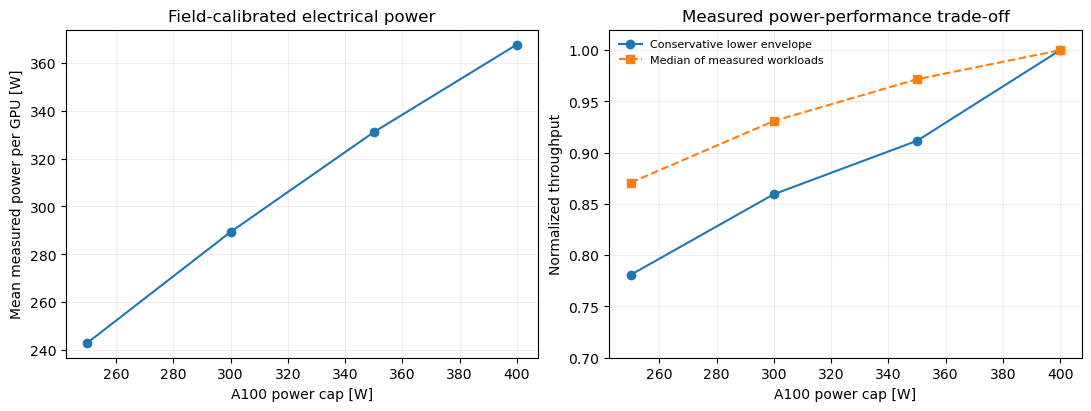

In [11]:
# Figure A: field-measured DVFS calibration used in the model.
fig, axes = plt.subplots(1,2,figsize=(10.8,4.0),constrained_layout=True)
axes[0].plot(cal.power_cap_W, cal.model_power_per_gpu_kW*1000, marker='o')
axes[0].set_xlabel('A100 power cap [W]')
axes[0].set_ylabel('Mean measured power per GPU [W]')
axes[0].set_title('Field-calibrated electrical power')
axes[0].grid(alpha=.2)
axes[1].plot(cal.power_cap_W, cal.model_throughput_factor, marker='o', label='Conservative lower envelope')
axes[1].plot(cal.power_cap_W, cal.throughput_median, marker='s', linestyle='--', label='Median of measured workloads')
axes[1].set_xlabel('A100 power cap [W]')
axes[1].set_ylabel('Normalized throughput')
axes[1].set_ylim(0.7,1.02)
axes[1].set_title('Measured power-performance trade-off')
axes[1].legend(frameon=False,fontsize=8)
axes[1].grid(alpha=.2)
fig.savefig(OUT/'fig_field_dvfs_calibration.pdf',bbox_inches='tight')
plt.show()

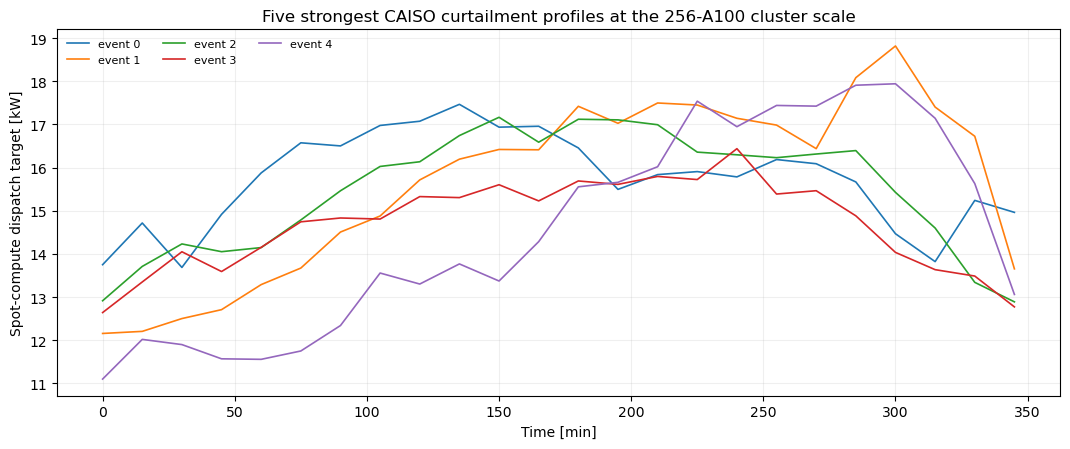

In [12]:
# Figure B: real CAISO events mapped to the field-calibrated 25%-of-cluster flexible envelope.
fig, ax = plt.subplots(figsize=(10.8,4.6))
for eid in [0,1,2,3,4]:
    ep = profiles[profiles.event_id==eid].sort_values('slot')
    ax.plot(ep.slot*CFG.slot_minutes, ep.dispatch_target_kW, lw=1.2, label=f'event {eid}')
ax.set_xlabel('Time [min]')
ax.set_ylabel('Spot-compute dispatch target [kW]')
ax.set_title('Five strongest CAISO curtailment profiles at the 256-A100 cluster scale')
ax.grid(alpha=.2); ax.legend(frameon=False,ncol=3,fontsize=8)
fig.tight_layout(); fig.savefig(OUT/'fig_scaled_caiso_targets.pdf',bbox_inches='tight'); plt.show()

## Interpretation before solver benchmarking

The preparation stage should produce approximately:

- 18 real Alibaba Spot A100 jobs;
- exactly 256 GPUs in the complete queued portfolio;
- four measured DVFS modes (250, 300, 350 and 400 W);
- about 945 candidate binaries;
- a very dense quadratic graph (about 94% of all possible pairs);
- an exact direct/QUBO identity at numerical precision.

The greedy check is only a feasibility diagnostic. The next notebook performs the actual 30-s CPLEX and simulated-annealing tests. **Do not spend D-Wave quota before notebook 02B is reviewed.**